# AgroIntelli — Training, Evaluation, and Export Notebook

This notebook is the full training pipeline for the project and is designed to be run as a single notebook in:

- Google Colab
- Windows Jupyter Notebook / JupyterLab
- VS Code notebooks

## What this notebook does

1. downloads the dataset from Mendeley  
2. detects the correct dataset root automatically  
3. splits raw data first  
4. builds TensorFlow datasets  
5. trains a lightweight MobileNetV3Small model  
6. fine-tunes the backbone in a second stage  
7. evaluates with proper metrics  
8. shows random test images and manual image inference  
9. generates Grad-CAM heatmaps  
10. estimates image quality and severity  
11. exports a quantized TFLite model for offline deployment  

## Important note

Training uses the standard float model first.  
Quantization happens only during export.

## 0) Setup

This cell creates a small workspace inside the current folder.
Nothing needs to be created manually.

In [1]:
# If needed in a fresh environment:
# !pip install tensorflow scikit-learn pandas matplotlib pillow opencv-python

from pathlib import Path
import os
import json
import random
import shutil
import zipfile
import urllib.request
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

print("TensorFlow:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd() / "AgroIntelli_Standalone"
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
EXTRACTED_DIR = DATA_DIR / "extracted"
SPLITS_DIR = DATA_DIR / "splits"
TRAIN_DIR = SPLITS_DIR / "train"
VAL_DIR = SPLITS_DIR / "val"
TEST_DIR = SPLITS_DIR / "test"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PLOTS_DIR = OUTPUTS_DIR / "plots"

for p in [PROJECT_ROOT, DATA_DIR, RAW_DIR, EXTRACTED_DIR, SPLITS_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR, ARTIFACTS_DIR, OUTPUTS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Workspace ready.")

TensorFlow: 2.21.0
Project root: C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone
Workspace ready.


## 1) Download the dataset

We use the exact Mendeley link provided by you.
The code is pure Python, so it works in both Colab and Windows Jupyter.

In [2]:
DATA_URL = "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"
ZIP_PATH = RAW_DIR / "dataset.zip"

def download_file(url, dst):
    if dst.exists() and dst.stat().st_size > 0:
        print("Already downloaded:", dst)
        return
    print("Downloading dataset...")
    import urllib.request
    req = urllib.request.Request(url, headers={
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    })
    with urllib.request.urlopen(req) as resp, open(dst, "wb") as out:
        total = int(resp.headers.get("Content-Length", 0))
        downloaded = 0
        chunk_size = 1 << 20
        while True:
            chunk = resp.read(chunk_size)
            if not chunk:
                break
            out.write(chunk)
            downloaded += len(chunk)
            if total:
                pct = downloaded * 100 // total
                print(f"\r  {pct}%  ({downloaded >> 20} / {total >> 20} MB)", end="", flush=True)
    print("\nSaved to:", dst)

def unzip_file(zip_path, extract_to):
    marker = extract_to / ".unzipped_ok"
    if marker.exists():
        print("Dataset already extracted.")
        return
    print("Extracting dataset...")
    import zipfile
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    marker.write_text("ok", encoding="utf-8")
    print("Extraction complete.")

download_file(DATA_URL, ZIP_PATH)
unzip_file(ZIP_PATH, EXTRACTED_DIR)


Already downloaded: C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\data\raw\dataset.zip
Dataset already extracted.


## 2) Automatically find the real dataset root

Some archives contain nested folders.

This step searches for the folder that actually holds the class subfolders.
If a `without_augmentation` folder exists, it is preferred because we are doing augmentation inside the model.

In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def score_dataset_candidate(folder):
    if not folder.exists() or not folder.is_dir():
        return (0, 0)
    class_count = 0
    image_count = 0
    for d in folder.iterdir():
        if d.is_dir():
            imgs = [p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]
            if imgs:
                class_count += 1
                image_count += len(imgs)
    return class_count, image_count

def find_best_dataset_root(search_root):
    preferred_names = [
        "Plant_leave_diseases_dataset_without_augmentation",
        "Plant_leave_diseases_dataset_with_augmentation",
    ]
    for name in preferred_names:
        candidate = search_root / name
        if candidate.exists():
            c, n = score_dataset_candidate(candidate)
            if c >= 2 and n >= 50:
                return candidate

    candidates = []
    for p in search_root.rglob("*"):
        if p.is_dir():
            c, n = score_dataset_candidate(p)
            if c >= 2 and n >= 50:
                candidates.append((c, n, p))
    if not candidates:
        raise FileNotFoundError("No usable dataset root found.")
    candidates.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][2]

DATASET_ROOT = find_best_dataset_root(EXTRACTED_DIR)
print("Selected dataset root:", DATASET_ROOT)
print("Score:", score_dataset_candidate(DATASET_ROOT))

Selected dataset root: C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\data\extracted\Plant_leave_diseases_dataset_with_augmentation
Score: (39, 61486)


## 3) Inspect the dataset

Before training, we confirm:
- how many classes exist
- how many images exist
- whether images load correctly

This prevents path mistakes and gives confidence that the data is valid.

In [4]:
def discover_images(root_dir):
    rows = []
    class_names = []
    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        imgs = [fp for fp in class_dir.rglob("*") if fp.is_file() and fp.suffix.lower() in IMG_EXTS]
        if imgs:
            class_names.append(class_dir.name)
            for fp in imgs:
                rows.append({"filepath": str(fp), "class_name": class_dir.name})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No images found under the selected dataset root.")
    return df, class_names

df, class_names = discover_images(DATASET_ROOT)
print("Total images:", len(df))
print("Total classes:", len(class_names))
display(df["class_name"].value_counts().head(10))

Total images: 61486
Total classes: 39


class_name
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight                             1909
Squash___Powdery_mildew                          1835
Tomato___Septoria_leaf_spot                      1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Name: count, dtype: int64

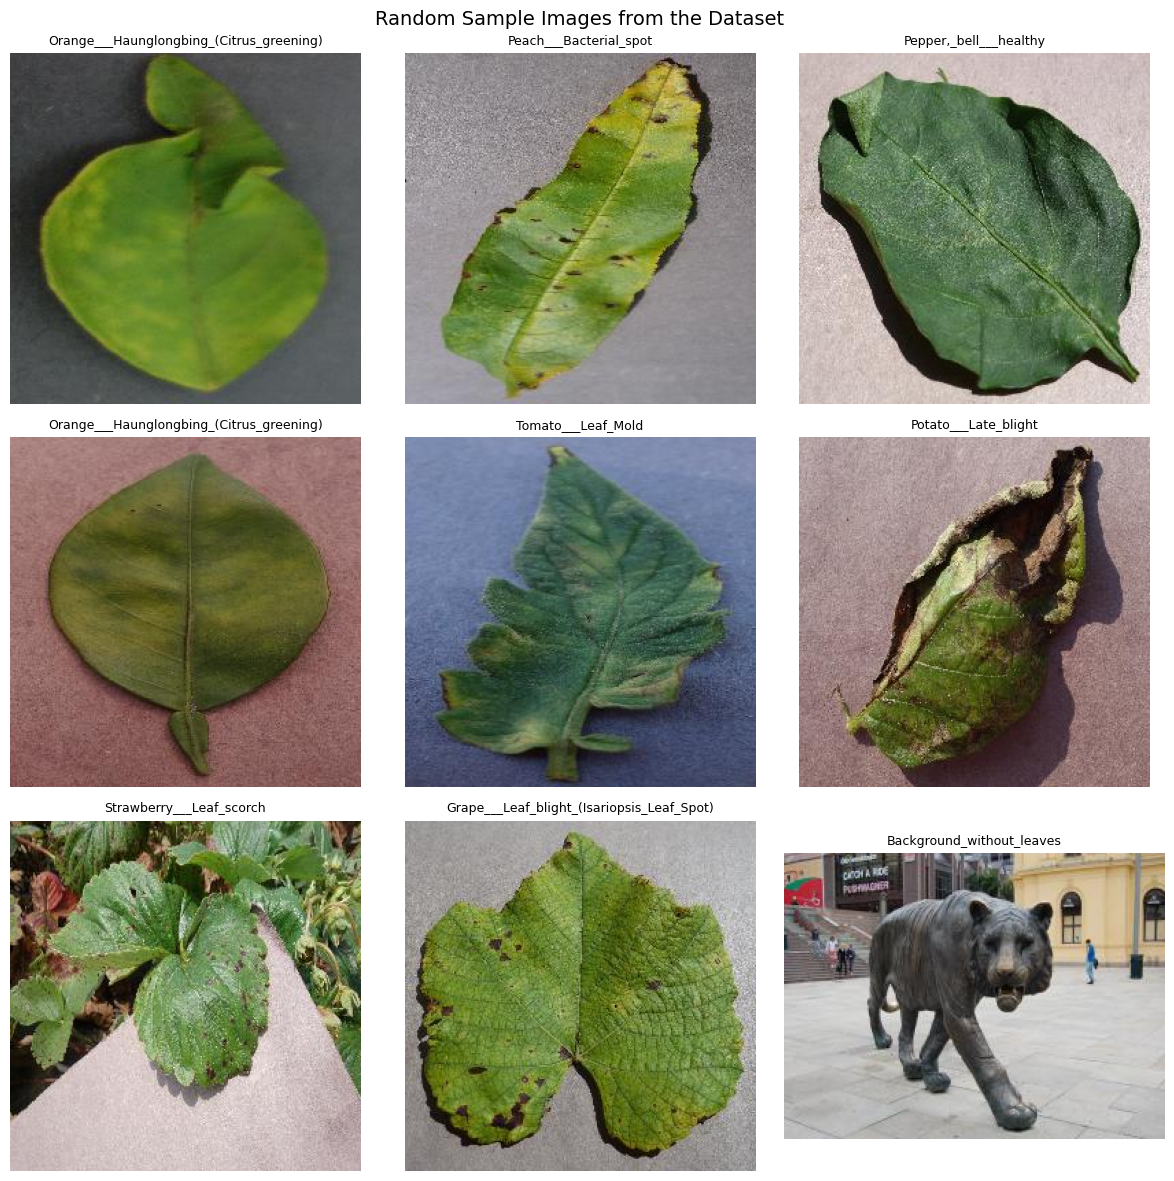

In [5]:
sample_df = df.sample(n=min(9, len(df)), random_state=SEED)

plt.figure(figsize=(12, 12))
for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    ax = plt.subplot(3, 3, i)
    img = Image.open(row["filepath"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(row["class_name"], fontsize=9)
    ax.axis("off")
plt.suptitle("Random Sample Images from the Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 4) Split the raw data first

We split before augmentation and before training so that validation and test results remain honest.

In [6]:
class_to_idx = {name: i for i, name in enumerate(sorted(class_names))}
df["label"] = df["class_name"].map(class_to_idx).astype(int)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

train_df.to_csv(PROJECT_ROOT / "train_manifest.csv", index=False)
val_df.to_csv(PROJECT_ROOT / "val_manifest.csv", index=False)
test_df.to_csv(PROJECT_ROOT / "test_manifest.csv", index=False)

with open(ARTIFACTS_DIR / "class_names.json", "w") as f:
    json.dump(sorted(class_names), f, indent=2)

print("Manifests saved.")
def copy_splits(manifest_df, dest_dir):
    for _, row in manifest_df.iterrows():
        src = Path(row["filepath"])
        cls_dir = dest_dir / row["class_name"]
        cls_dir.mkdir(parents=True, exist_ok=True)
        dst = cls_dir / src.name
        if not dst.exists():
            import shutil
            shutil.copy2(src, dst)

copy_splits(train_df, TRAIN_DIR)
copy_splits(val_df, VAL_DIR)
copy_splits(test_df, TEST_DIR)
print("Split directories populated.")


Train: 43040
Val:   9223
Test:  9223
Manifests saved.
Split directories populated.


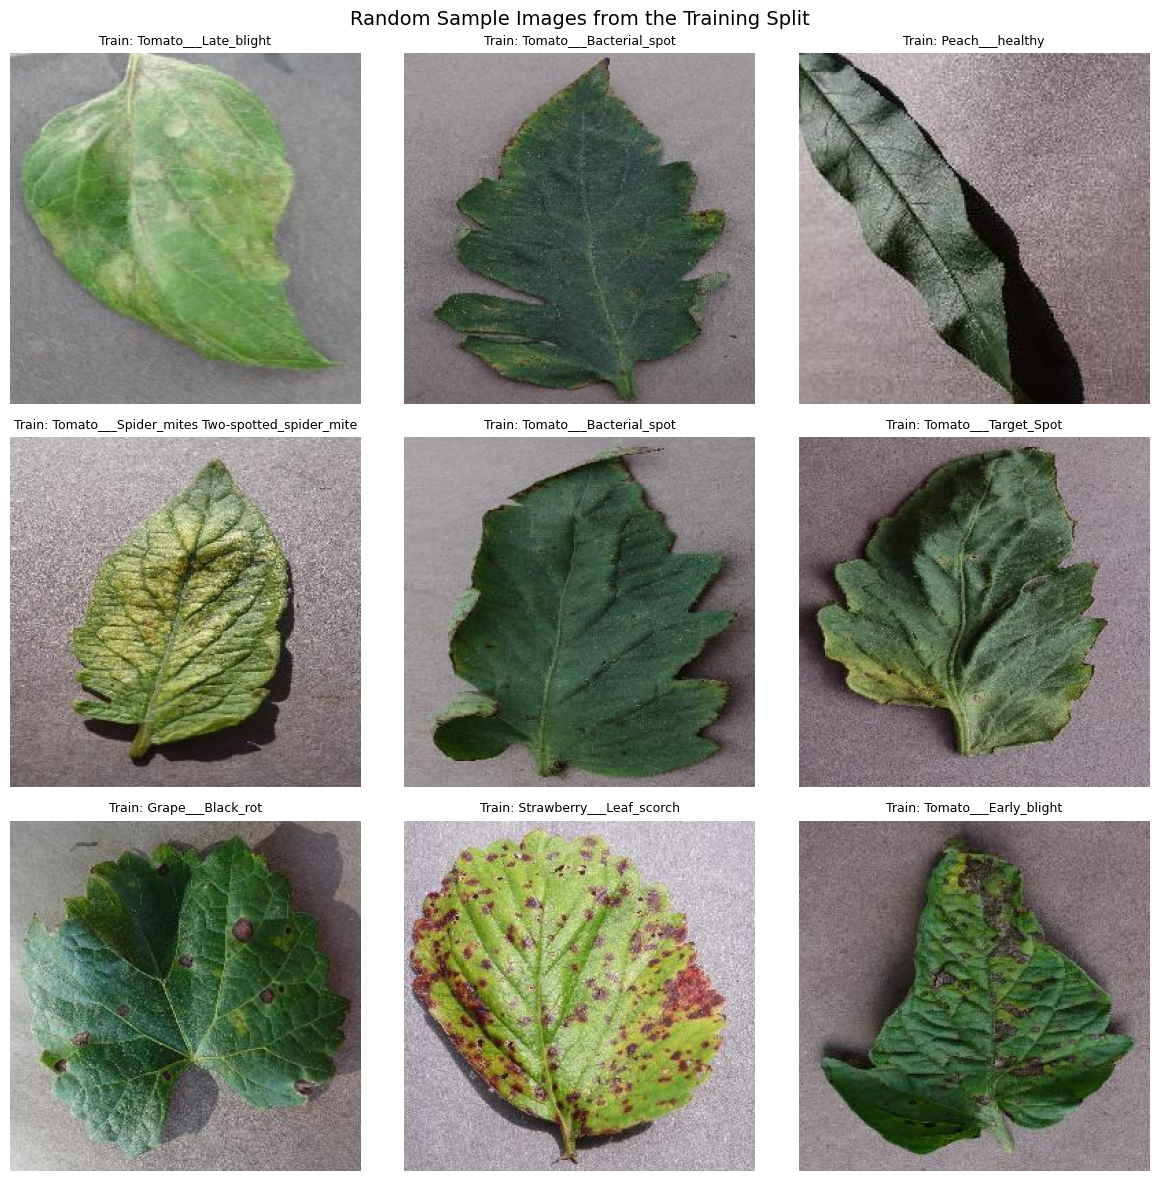

In [7]:
train_preview = train_df.sample(n=min(9, len(train_df)), random_state=SEED)

plt.figure(figsize=(12, 12))
for i, (_, row) in enumerate(train_preview.iterrows(), start=1):
    ax = plt.subplot(3, 3, i)
    img = Image.open(row["filepath"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Train: {row['class_name']}", fontsize=9)
    ax.axis("off")
plt.suptitle("Random Sample Images from the Training Split", fontsize=14)
plt.tight_layout()
plt.show()

## 5) Build TensorFlow datasets

The files are already split.

Now we convert the image paths into fast TensorFlow datasets.

In [8]:
IMG_SIZE = 160
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(frame, training=False):
    paths = frame["filepath"].values
    labels = frame["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED, reshuffle_each_iteration=True)

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.io.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32)
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Datasets ready.")

Datasets ready.


## 6) Build the model

We use **MobileNetV3Small** because it is light, mobile-friendly, and still strong enough for a student project.

We train the model in float32 first and quantize it later during export.

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomTranslation(0.05, 0.05),
], name="augmentation")

backbone = keras.applications.MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=False,
)

backbone.trainable = False

def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    # Scale to [-1, 1] because include_preprocessing=False removed the built-in scaling
    x = layers.Rescaling(1./127.5, offset=-1)(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(len(class_names), activation="softmax")(x)
    return keras.Model(inputs, outputs, name="AgroIntelli_MobileNetV3Small")

model = build_model()
model.summary()

C:\Users\rahul\Downloads\AgroIntelli_Full_Project\venv311\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "AgroIntelli_MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape        ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 160, 160, 3) │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ augmentation (Sequential)   │ (None, 160, 160, 3) │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ rescaling (Rescaling)       │ (None, 160, 160, 3) │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ MobileNetV3Small            │ (None, 5, 5, 576)   │     939,120 │
│ (Functional)                │                     │             │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ global_average_pooling2d    │ (None, 576)         │           0 │
│ (GlobalAveragePooling2D)    │                     │             │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dropout (Dropout)           │ (None, 576)         │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense (Dense)               │ (None, 128)         │      73,856 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dropout_1 (Dropout)         │ (None, 128)         │           0 │
├─────────────────────────────┼─────────────────────┼─────────────┤
│ dense_1 (Dense)             │ (None, 39)          │       5,031 │
└─────────────────────────────┴─────────────────────┴─────────────┘

 Total params: 1,018,007 (3.88 MB)

 Trainable params: 78,887 (308.15 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 7) Class imbalance handling

If some disease classes have fewer samples, the model may ignore them.

Class weights reduce this bias during training.

In [10]:
train_labels = train_df["label"].values
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {int(k): float(v) for k, v in zip(np.unique(train_labels), weights)}
class_weights

{0: 1.5765567765567765,
 1: 1.5765567765567765,
 2: 1.5765567765567765,
 3: 0.957977207977208,
 4: 1.3794871794871795,
 5: 1.050037815023543,
 6: 1.499442586399108,
 7: 1.5765567765567765,
 8: 1.5765567765567765,
 9: 1.3232490930332657,
 10: 1.5765567765567765,
 11: 1.3574289589049737,
 12: 1.3360650648786243,
 13: 1.1400720491629583,
 14: 1.4655906289372425,
 15: 1.5765567765567765,
 16: 0.28627490106089326,
 17: 0.6863120295956117,
 18: 1.5765567765567765,
 19: 1.5765567765567765,
 20: 1.066270283661588,
 21: 1.5765567765567765,
 22: 1.5765567765567765,
 23: 1.5765567765567765,
 24: 1.5765567765567765,
 25: 0.309736105413905,
 26: 0.8588247031826798,
 27: 1.422151731430082,
 28: 1.5765567765567765,
 29: 0.7411616813900226,
 30: 1.5765567765567765,
 31: 0.826040227237832,
 32: 1.5765567765567765,
 33: 0.8899917287014061,
 34: 0.9408267208778718,
 35: 1.1226752223700343,
 36: 0.2942905982905983,
 37: 1.5765567765567765,
 38: 0.9906550660590158}

## 8) Training callbacks

- **ModelCheckpoint** saves the best model  
- **EarlyStopping** stops when validation loss stops improving  
- **ReduceLROnPlateau** lowers the learning rate when the model plateaus

In [11]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

loss_fn = keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

## 9) Stage A training

We first freeze the backbone and train only the classification head.

In [12]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/12
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5587 - loss: 1.6026
Epoch 1: val_loss improved from None to 0.46997, saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras

Epoch 1: finished saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 184s 66ms/step - accuracy: 0.6920 - loss: 1.0501 - val_accuracy: 0.8520 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 2/12
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7998 - loss: 0.6154
Epoch 2: val_loss improved from 0.46997 to 0.42756, saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras

Epoch 2: finished saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 17

## 10) Stage B fine-tuning

Now we unfreeze only the later backbone layers and continue training with a much smaller learning rate.

In [13]:
backbone.trainable = True

for layer in backbone.layers[:-40]:
    layer.trainable = False

for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=callbacks,
)

model.save(ARTIFACTS_DIR / "agrointelli_final.keras")
print("Final Keras model saved.")

Epoch 1/8
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8798 - loss: 0.3645
Epoch 1: val_loss improved from 0.24419 to 0.22102, saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras

Epoch 1: finished saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 211s 75ms/step - accuracy: 0.8913 - loss: 0.3299 - val_accuracy: 0.9270 - val_loss: 0.2210 - learning_rate: 1.0000e-05
Epoch 2/8
2690/2690 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9058 - loss: 0.2788
Epoch 2: val_loss improved from 0.22102 to 0.20043, saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras

Epoch 2: finished saving model to C:\Users\rahul\Downloads\AgroIntelli_Full_Project\notebooks\AgroIntelli_Standalone\artifacts\best_model.keras
2690/2690 ━━━━━━━━━━━━━━━━━━

## 11) Plot the training curves

These curves help us see whether the model is learning properly or overfitting.

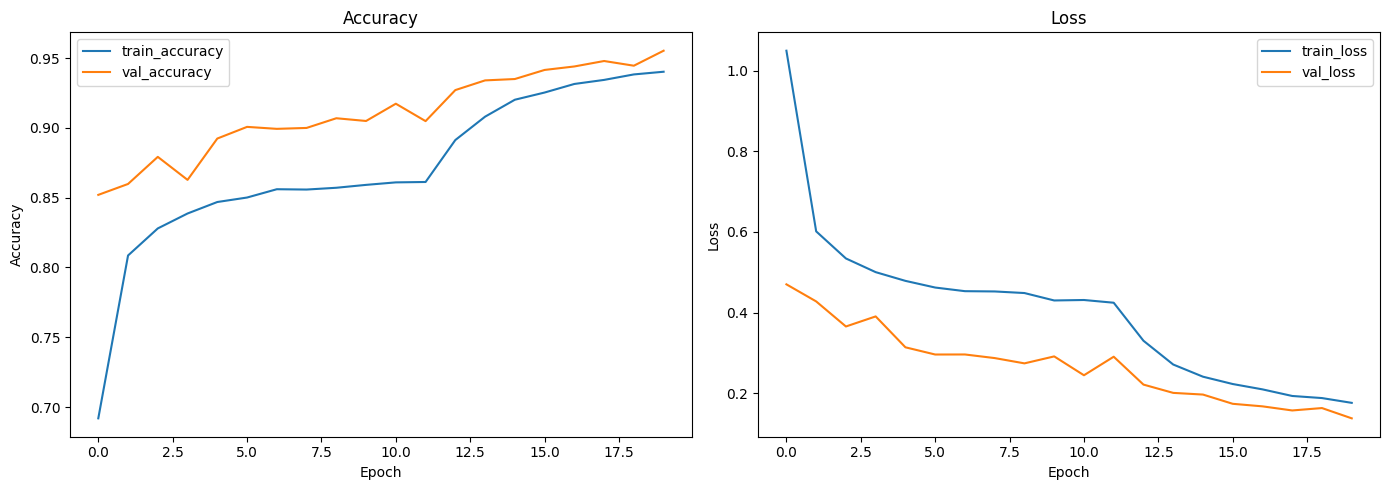

In [14]:
def plot_history(h1, h2):
    hist = {
        "accuracy": h1.history.get("accuracy", []) + h2.history.get("accuracy", []),
        "val_accuracy": h1.history.get("val_accuracy", []) + h2.history.get("val_accuracy", []),
        "loss": h1.history.get("loss", []) + h2.history.get("loss", []),
        "val_loss": h1.history.get("val_loss", []) + h2.history.get("val_loss", []),
    }

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_stage1, history_stage2)

## 12) Evaluate on the test set

We report more than accuracy:
- accuracy
- macro precision
- macro recall
- macro F1-score
- classification report
- confusion matrix

In [15]:
def collect_predictions(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        y_true.append(yb.numpy())
        y_prob.append(probs)
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

y_true, y_pred, y_prob = collect_predictions(model, test_ds)

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

print(f"Test Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall:    {rec:.4f}")
print(f"Macro F1:        {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=sorted(class_names), zero_division=0))

Test Accuracy: 0.9578
Macro Precision: 0.9521
Macro Recall:    0.9579
Macro F1:        0.9540

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.94      0.96      0.95       150
                            Apple___Black_rot       0.97      0.97      0.97       150
                     Apple___Cedar_apple_rust       0.99      1.00      0.99       150
                              Apple___healthy       0.93      0.98      0.95       246
                    Background_without_leaves       0.99      0.98      0.99       171
                          Blueberry___healthy       0.97      1.00      0.98       225
                      Cherry___Powdery_mildew       0.97      0.98      0.97       158
                             Cherry___healthy       0.99      1.00      0.99       150
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.86      0.90       150
                           Corn___

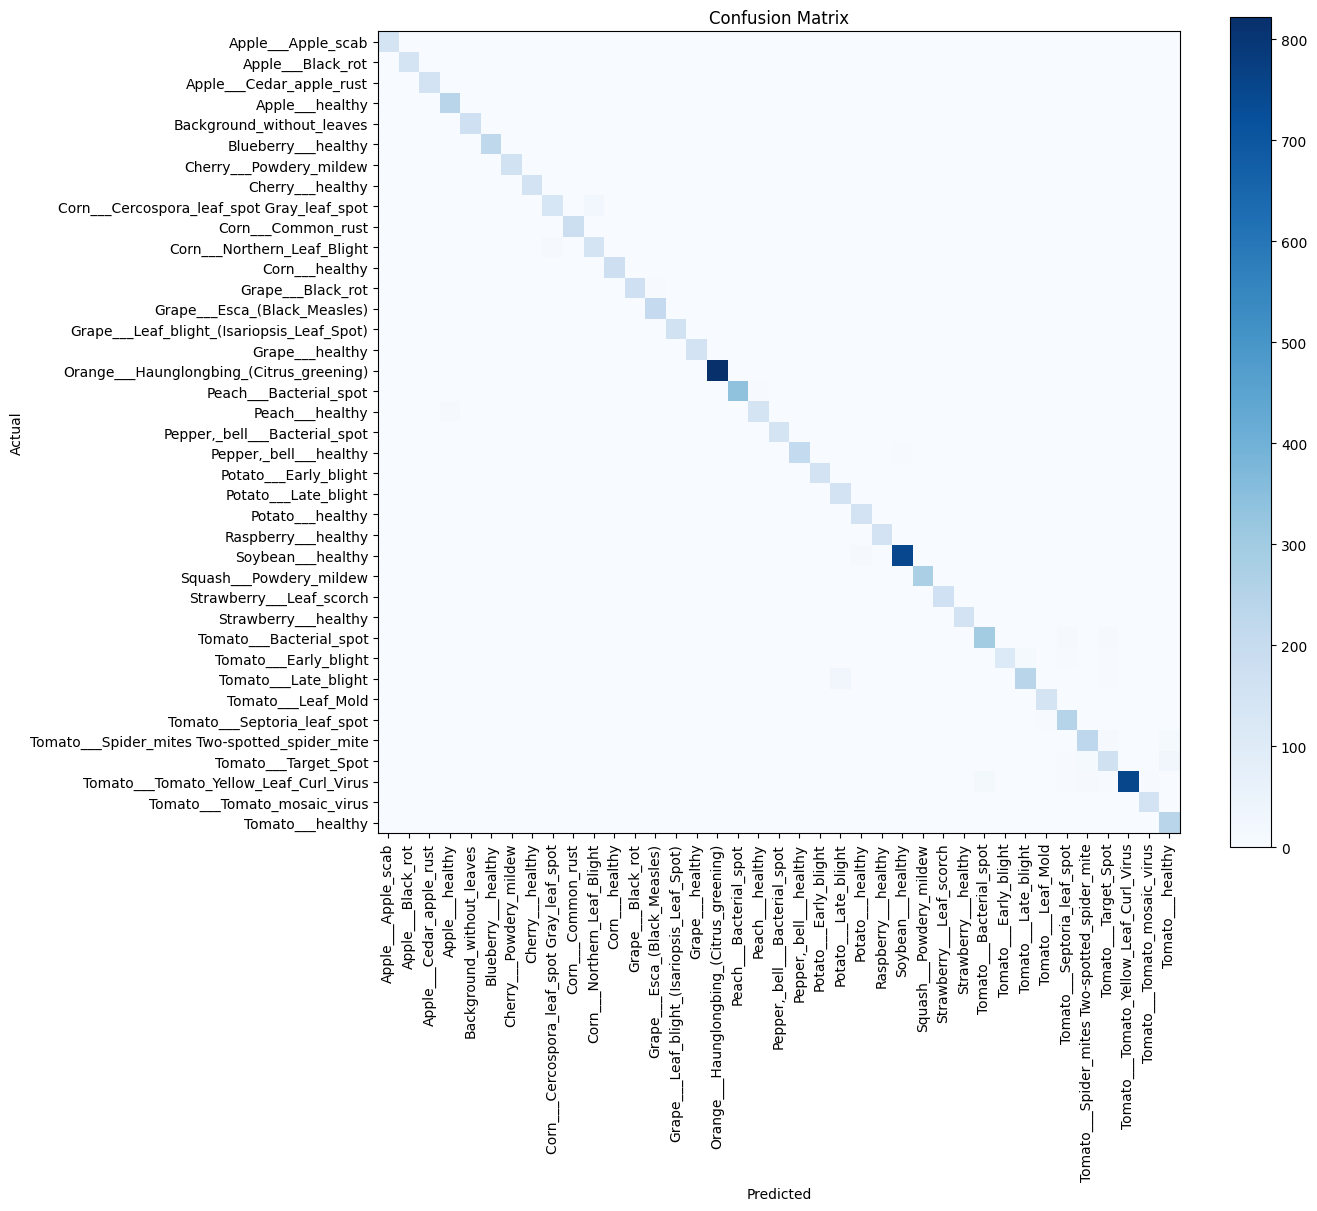

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), sorted(class_names), rotation=90)
plt.yticks(range(len(class_names)), sorted(class_names))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 13) Image quality check

This is a practical helper for the final project.

It checks:
- brightness
- contrast
- blur

If the image is poor quality, the app can warn the user before running inference.

In [22]:
def image_quality_check(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return {"ok": False, "reason": "image not readable"}

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())
    contrast = float(gray.std())
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    warnings = []
    if brightness < 50:
        warnings.append("too dark")
    elif brightness > 205:
        warnings.append("too bright")
    if contrast < 20:
        warnings.append("low contrast")
    if sharpness < 60:
        warnings.append("blurry")

    return {
        "ok": len(warnings) == 0,
        "brightness": brightness,
        "contrast": contrast,
        "sharpness": sharpness,
        "warnings": warnings,
    }

## 14) Severity proxy

True severity scoring needs better field annotations.

With PlantVillage, we can still create a useful severity proxy for a demo:
- healthy / very mild
- early / moderate
- severe

In [23]:
def severity_proxy(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return {"severity": "unknown", "lesion_ratio": 0.0}

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    leaf = (hsv[:, :, 1] > 40) & (hsv[:, :, 2] > 40)
    if leaf.sum() < 100:
        return {"severity": "unknown", "lesion_ratio": 0.0}

    bgr = img.astype(np.int16)
    lesion = leaf & ((bgr[:, :, 1] < 120) | (bgr[:, :, 2] > 140))
    ratio = float(lesion.sum() / leaf.sum())

    if ratio < 0.08:
        sev = "healthy/very mild"
    elif ratio < 0.22:
        sev = "early/moderate"
    else:
        sev = "severe"

    return {"severity": sev, "lesion_ratio": ratio}

## 15) Grad-CAM explainability

Grad-CAM shows where the model is looking when it predicts a class.

In [24]:
def get_last_conv_layer_name(backbone_model):
    conv_layers = [layer.name for layer in backbone_model.layers if isinstance(layer, layers.Conv2D)]
    if not conv_layers:
        raise ValueError("No Conv2D layer found in backbone.")
    return conv_layers[-1]

def make_gradcam_heatmap(image_path, model, backbone_model):
    img = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras.utils.img_to_array(img)[None, ...].astype(np.float32)

    last_conv_name = get_last_conv_layer_name(backbone_model)
    grad_model = keras.Model(
        [model.inputs],
        [backbone_model.get_layer(last_conv_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(arr)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(image_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heat = make_gradcam_heatmap(image_path, model, backbone)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heat, cmap="jet", alpha=0.35)
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.tight_layout()
    plt.show()

## 16) Prediction helper

This combines:
- disease prediction
- confidence
- top-3 classes
- image quality check
- severity proxy
- advice
- field/lab mode logic

In [25]:
ADVICE_RULES = [
    ("blight", "Remove infected leaves and avoid overhead watering."),
    ("rust", "Improve airflow and monitor spread carefully."),
    ("scab", "Use sanitation and monitor leaf surfaces."),
    ("spot", "Reduce leaf wetness and remove affected leaves."),
    ("mosaic", "Control vectors and remove infected plants if needed."),
    ("healthy", "No obvious disease detected. Keep monitoring regularly."),
]

def get_care_advice(class_name):
    low = class_name.lower()
    for key, advice in ADVICE_RULES:
        if key in low:
            return advice
    return "No specific advice found. Continue monitoring and compare with crop guidance."

def predict_single(image_path, field_mode=True):
    quality = image_quality_check(image_path)
    severity = severity_proxy(image_path)

    img = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras.utils.img_to_array(img)[None, ...].astype(np.float32)

    probs = model.predict(arr, verbose=0)[0]
    order = np.argsort(probs)[::-1]
    top3 = [(sorted(class_names)[i], float(probs[i])) for i in order[:3]]

    best_class, best_conf = top3[0]

    if field_mode:
        if best_conf >= 0.85:
            mode = "high confidence"
        elif best_conf >= 0.55:
            mode = "medium confidence"
        else:
            mode = "low confidence"
    else:
        mode = "lab mode"

    return {
        "prediction": best_class,
        "confidence": float(best_conf),
        "top3": top3,
        "mode": mode,
        "quality": quality,
        "severity_proxy": severity,
        "advice": get_care_advice(best_class),
    }

# Example:
# result = predict_single("path/to/leaf.jpg", field_mode=True)
# print(result)

## 17) Random test-image reality check

This cell samples random images from the test split and runs the full prediction pipeline.

It uses paths from the test dataframe, which is the correct and simplest way.

In [26]:
sample_files = []
for cls in sorted(class_names):
    cls_dir = TEST_DIR / cls
    if cls_dir.exists():
        imgs = [f for f in cls_dir.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXTS]
        if imgs:
            sample_files.append(random.choice(imgs))

random.shuffle(sample_files)
sample_files = sample_files[:5]

for img_path in sample_files:
    res = predict_single(str(img_path), field_mode=True)
    print(f"\nIMAGE: {img_path.name}")
    print("Prediction:", res["prediction"])
    print("Confidence:", round(res["confidence"], 4))
    print("Top-3:", res["top3"])
    print("Quality:", res["quality"])
    print("Severity:", res["severity_proxy"])
    print("Advice:", res["advice"])
    show_gradcam(str(img_path))



IMAGE: image (638).JPG
Prediction: Corn___Northern_Leaf_Blight
Confidence: 0.9992
Top-3: [('Corn___Northern_Leaf_Blight', 0.9992029070854187), ('Corn___Cercospora_leaf_spot Gray_leaf_spot', 0.0007940380019135773), ('Corn___Common_rust', 1.975180794033804e-06)]
Quality: {'ok': True, 'brightness': 121.00810241699219, 'contrast': 29.908268543102704, 'sharpness': 1465.2509877027478, 'warnings': []}
Severity: {'severity': 'severe', 'lesion_ratio': 0.5267234701781565}
Advice: Remove infected leaves and avoid overhead watering.


ValueError: Output with path `0` is not connected to `inputs`

## 18) Manual image testing

You can test your own image by setting a file path manually.

If you are in Colab, you can also upload a leaf image and use the uploaded filename.

In [27]:
# Manual local example:
# manual_image_path = "path/to/your/leaf.jpg"
# result = predict_single(manual_image_path, field_mode=True)
# print(result)
# show_gradcam(manual_image_path)

In [28]:
manual_image_path = None

try:
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    if uploaded:
        manual_image_path = next(iter(uploaded.keys()))
        print("Uploaded:", manual_image_path)
except Exception:
    pass

if manual_image_path:
    result = predict_single(manual_image_path, field_mode=True)
    print(result)
    show_gradcam(manual_image_path)
else:
    print("No uploaded manual image in this run.")

No uploaded manual image in this run.


## 19) TFLite export

This is the deployment step.

The model is converted to a quantized TFLite file for offline use later in the mobile app.

In [29]:
keras_model = keras.models.load_model(ARTIFACTS_DIR / "agrointelli_final.keras")
print("Loaded final model:", keras_model.name)

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "agrointelli_quant.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model:", tflite_path)
print("TFLite size (MB):", round(tflite_path.stat().st_size / (1024 * 1024), 2))

Loaded final model: AgroIntelli_MobileNetV3Small
INFO:tensorflow:Assets written to: C:\Users\rahul\AppData\Local\Temp\tmpvut5bd5y\assets


INFO:tensorflow:Assets written to: C:\Users\rahul\AppData\Local\Temp\tmpvut5bd5y\assets


Saved artifact at 'C:\Users\rahul\AppData\Local\Temp\tmpvut5bd5y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 39), dtype=tf.float32, name=None)
Captures:
  1547130988560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130990672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130992208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130988176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130990480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130989712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130989904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547231819728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130991632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1547130992016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  154

In [30]:
with open(ARTIFACTS_DIR / "labels.txt", "w") as f:
    for c in sorted(class_names):
        f.write(c + "\n")

advice_map = {
    c: {
        "summary": get_care_advice(c),
        "prevention": "Keep the plant dry, monitor regularly, and remove infected tissue if needed."
    }
    for c in sorted(class_names)
}

with open(ARTIFACTS_DIR / "advice.json", "w") as f:
    json.dump(advice_map, f, indent=2)

print("Saved labels.txt and advice.json")

Saved labels.txt and advice.json


## 20) Final summary

### What this notebook contains
- dataset download
- automatic root detection
- random dataset preview
- raw split first
- MobileNetV3Small training
- class weights
- callbacks
- two-stage training
- evaluation
- Grad-CAM
- quality check
- severity proxy
- field/lab logic
- random test-image reality check
- manual image testing
- TFLite export

### What remains future work
- real multi-disease / multi-label awareness
- field-annotated severity training
- full mobile packaging